# Phase 2a, Exact oracle + four baselines

**Problem (locked).** Given $\hat\mu\in\mathbb{R}^n$ and $\hat\Sigma\in\mathbb{R}^{n\times n}$ estimated from the **first 80%** of the return matrix $R$ (2010 days), pick a **cardinality-$k$** subset $S\subset\{1,\dots,n\}$ with equal weights $w_i=1/k$ on $i\in S$ to maximize the regularized return
$$
J(\sigma) \;=\; \frac{1}{k}\,\hat\mu^\top\sigma \;-\; \frac{\gamma}{2k^2}\,\sigma^\top\hat\Sigma\,\sigma
\quad\text{subject to}\quad
\sigma\in\{0,1\}^n,\ \sum_i\sigma_i=k,
$$
with $\gamma=10$. Out-of-sample evaluation: annualized Sharpe ratio of the equal-weighted portfolio on the **last 20%** (502 days).

**Why this objective.** Equal weights collapse the continuous Markowitz inner problem, so the *only* decision variable is the binary support $\sigma$, exactly the regime in which OGP, MCMC mixing, and our hybrid-spectral algorithm all live. This is the cleanest combinatorial formulation; everything in Phases 3-4 will reference $J(\sigma)$ above.

**Algorithms compared.**

| Algorithm | Type | Cost | What it tells us |
|---|---|---|---|
| Brute force enumeration | Exact oracle | $\binom{n}{k}$ | Ground truth $J^\star$ |
| Long multistart simulated annealing | Near-oracle | $\sim 10^6$ swaps | Upper bound when $\binom{n}{k}$ too big |
| Top-eigenvector | Spectral heuristic | $O(n^3)$ | Will become our **hybrid seed** in Phase 4 |
| Greedy forward selection | Combinatorial | $O(n\,k)$ | Standard MIQP heuristic baseline |
| LASSO-Markowitz | Convex relaxation | one continuous QP | The convex thing the standard compressive-sensing lemma would justify, *if* RIP held, Phase 1 showed RIP fails |
| Single-shot simulated annealing | Local search | $\sim 10^4$ swaps | Cheap MCMC baseline |

**Outputs:** `data/oracle_baselines.json`, `data/figs/oracle_vs_baselines.png`, `data/figs/oracle_runtime.png`.

## 0. Setup, data load, train/test split

In [1]:
from __future__ import annotations

import json
import time
from itertools import combinations
from math import comb
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
FIG_DIR = DATA_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

GAMMA = 10.0
TRAIN_FRAC = 0.80
TRADING_DAYS = 252

rng_global = np.random.default_rng(0)

R_full = np.load(DATA_DIR / "returns.npy")
tickers_full = pd.read_csv(DATA_DIR / "tickers.csv", header=None).iloc[:, 0].tolist()
T_full, n_full = R_full.shape
T_tr = int(TRAIN_FRAC * T_full)
R_train_full = R_full[:T_tr]
R_test_full = R_full[T_tr:]
print(f"Full panel:  T={T_full}, n={n_full}")
print(f"Train:       T_tr={T_tr}  ({R_full.dtype})")
print(f"Test:        T_te={T_full - T_tr}")
print(f"gamma = {GAMMA}, equal weights w_i = 1/k")

Full panel:  T=2512, n=468
Train:       T_tr=2009  (float64)
Test:        T_te=503
gamma = 10.0, equal weights w_i = 1/k


## 1. Core utilities, objective, Sharpe, instance sampler

Using vectorized form for speed. For brute force we will compute $J$ on chunks of subsets at a time.

In [2]:
def estimate_mu_sigma(R_train: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mu = R_train.mean(axis=0)
    Sigma = np.cov(R_train, rowvar=False)
    return mu, Sigma


def J(sigma: np.ndarray, mu: np.ndarray, Sigma: np.ndarray, k: int, gamma: float = GAMMA) -> float:
    """Equal-weight Markowitz objective on subset encoded by binary sigma."""
    s = sigma.astype(np.float64)
    return float(mu @ s) / k - gamma * float(s @ Sigma @ s) / (2.0 * k * k)


def J_from_support(S: np.ndarray, mu: np.ndarray, Sigma: np.ndarray, gamma: float = GAMMA) -> float:
    k = len(S)
    sub_mu = mu[S].sum()
    sub_var = Sigma[np.ix_(S, S)].sum()
    return sub_mu / k - gamma * sub_var / (2.0 * k * k)


def annualized_sharpe(R_period: np.ndarray, S: np.ndarray) -> float:
    """Equal-weight portfolio Sharpe on a return panel R_period (rows = days)."""
    pf = R_period[:, S].mean(axis=1)
    if pf.std(ddof=1) < 1e-12:
        return 0.0
    return float(np.sqrt(TRADING_DAYS) * pf.mean() / pf.std(ddof=1))


def sample_instance(n: int, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Pick n stocks uniformly at random from the full universe; return (mu, Sigma, R_train, R_test)."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_full, size=n, replace=False)
    Rtr = R_train_full[:, idx]
    Rte = R_test_full[:, idx]
    mu, Sigma = estimate_mu_sigma(Rtr)
    return mu, Sigma, Rtr, Rte


print("utilities ready")

utilities ready


## 2. Exact oracle by brute-force enumeration

**Vectorized enumeration.** We avoid a Python-level loop over $\binom{n}{k}$ subsets by:
1. Generating all $k$-subsets as an integer array of shape $\binom{n}{k}\times k$ in chunks,
2. Computing $\sum_{i\in S}\mu_i$ and $\sum_{i,j\in S}\Sigma_{ij}$ in NumPy for each chunk,
3. Tracking the running maximum.

Memory is bounded by the chunk size; runtime scales with $\binom{n}{k}\cdot k^2$ for the variance term.

Capped at $\binom{n}{k}\le 5\times 10^7$. For larger problems we fall back to a **long multistart SA** (Section 4).

In [3]:
BRUTE_FORCE_CAP = 50_000_000  # max number of subsets to enumerate exactly


def _chunked_combinations(n: int, k: int, chunk: int):
    """Yield arrays of shape (m, k) of k-subsets of range(n), m up to chunk."""
    it = combinations(range(n), k)
    while True:
        block = list()
        for _ in range(chunk):
            try:
                block.append(next(it))
            except StopIteration:
                if block:
                    yield np.asarray(block, dtype=np.int32)
                return
        yield np.asarray(block, dtype=np.int32)


def brute_force_oracle(
    mu: np.ndarray,
    Sigma: np.ndarray,
    k: int,
    gamma: float = GAMMA,
    chunk: int = 200_000,
    cap: int = BRUTE_FORCE_CAP,
) -> tuple[np.ndarray, float, dict]:
    n = len(mu)
    total = comb(n, k)
    if total > cap:
        raise ValueError(f"C({n},{k}) = {total:,} exceeds cap {cap:,}; use SA fallback")
    t0 = time.perf_counter()
    best_J = -np.inf
    best_S = None
    seen = 0
    for block in _chunked_combinations(n, k, chunk):
        # block has shape (m, k)
        mu_S = mu[block].sum(axis=1)  # (m,)
        # Sigma sub-sums: pull (m,k,k) block and sum over axis (1,2). For k<=12 this is tractable.
        # Use np.take / advanced indexing on 2D Sigma.
        # Sigma[block] has shape (m, k, n); then take along axis=2 with block:
        sub = Sigma[block[:, :, None], block[:, None, :]]  # (m, k, k)
        var_S = sub.sum(axis=(1, 2))  # (m,)
        Js = mu_S / k - gamma * var_S / (2.0 * k * k)
        local_max = int(np.argmax(Js))
        if Js[local_max] > best_J:
            best_J = float(Js[local_max])
            best_S = block[local_max].copy()
        seen += len(Js)
    elapsed = time.perf_counter() - t0
    info = {"n_subsets": int(total), "runtime_s": float(elapsed)}
    return np.sort(best_S), float(best_J), info


# tiny smoke test
mu_s, Sigma_s, _, _ = sample_instance(15, seed=42)
S_star, J_star, info_star = brute_force_oracle(mu_s, Sigma_s, k=4)
print(f"Smoke test: n=15, k=4 -> J*={J_star:.6f}, S*={S_star}, |subsets|={info_star['n_subsets']}, t={info_star['runtime_s']*1000:.1f} ms")

Smoke test: n=15, k=4 -> J*=0.000080, S*=[ 5  6  9 12], |subsets|=1365, t=3.6 ms


## 3. Baseline 1, Top-eigenvector heuristic

Pick the $k$ stocks whose loadings on the leading eigenvector $v_1$ of $\hat\Sigma$ have the largest absolute value. Phase 1 showed that $v_1$ is essentially the *market factor* (top-10 eigenvalues = 53% of variance), so this picks the most exposed assets, a *worst-case* heuristic for variance, which is why we expect it to be a poor baseline. It is included here because it is the natural starting point for our **hybrid spectral seed** in Phase 4 (where we will refine it via local search and connect to compressive sensing).

In [4]:
def top_eigenvector_baseline(mu: np.ndarray, Sigma: np.ndarray, k: int) -> np.ndarray:
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    v1 = eigvecs[:, -1]
    return np.sort(np.argsort(-np.abs(v1))[:k])


S_eig = top_eigenvector_baseline(mu_s, Sigma_s, k=4)
print(f"top-eig: S={S_eig}, J={J_from_support(S_eig, mu_s, Sigma_s):.6f}  vs J*={J_star:.6f}")

top-eig: S=[ 8 11 13 14], J=-0.000669  vs J*=0.000080


## 4. Baseline 2, Greedy forward selection

Start with $S=\emptyset$. At each of $k$ steps, add the asset $i\notin S$ that maximizes $J(S\cup\{i\})$. Cost: $O(nk)$ subset evaluations.

In [5]:
def greedy_forward(mu: np.ndarray, Sigma: np.ndarray, k: int, gamma: float = GAMMA) -> np.ndarray:
    n = len(mu)
    S: list[int] = []
    remaining = set(range(n))
    for _ in range(k):
        best_i, best_val = -1, -np.inf
        for i in remaining:
            cand = np.array(S + [i], dtype=np.int32)
            val = J_from_support(cand, mu, Sigma, gamma)
            if val > best_val:
                best_val, best_i = val, i
        S.append(best_i)
        remaining.remove(best_i)
    return np.sort(np.array(S, dtype=np.int32))


S_grd = greedy_forward(mu_s, Sigma_s, k=4)
print(f"greedy:  S={S_grd}, J={J_from_support(S_grd, mu_s, Sigma_s):.6f}  vs J*={J_star:.6f}")

greedy:  S=[ 5  6  9 12], J=0.000080  vs J*=0.000080


## 5. Baseline 3, LASSO-Markowitz

Solve the *continuous* Markowitz with an $\ell_1$ penalty,
$$
\min_{w\in\mathbb{R}^n} \quad \tfrac{\gamma}{2}\,w^\top\hat\Sigma w \;-\; \hat\mu^\top w \;+\; \lambda \|w\|_1,
$$
an unconstrained convex QP+$\ell_1$ that genuinely induces sparsity (note: combining $w\ge 0$ and $\mathbf 1^\top w=1$ would make $\|w\|_1\equiv 1$, killing the penalty). We bisect $\lambda$ until the active set has size $\ge k$, take the **top-$k$ coordinates by $|w|$**, and re-evaluate $J$ with equal weights, apples-to-apples with the other algorithms.

Phase 1 verdict: empirical RIP $\delta_k$ exceeds $1/3$ in the upper tail across all $k$, so Theorem 1 of standard compressive-sensing references does **not** justify LASSO recovery here. We benchmark it anyway and document the failure.

In [6]:
def _solve_lasso(mu: np.ndarray, Sigma: np.ndarray, gamma: float, lam_val: float) -> np.ndarray:
    n = len(mu)
    w = cp.Variable(n)
    obj = 0.5 * gamma * cp.quad_form(w, cp.psd_wrap(Sigma)) - mu @ w + lam_val * cp.norm1(w)
    prob = cp.Problem(cp.Minimize(obj))
    prob.solve(solver=cp.CLARABEL)
    if w.value is None:
        return np.zeros(n)
    return np.asarray(w.value).ravel()


def lasso_markowitz_support(
    mu: np.ndarray,
    Sigma: np.ndarray,
    k: int,
    gamma: float = GAMMA,
    thresh: float = 1e-5,
    max_iter: int = 25,
) -> np.ndarray:
    """Bisect lambda so |support| >= k, then take top-k by |w|."""
    n = len(mu)
    # Sensible initial bracket: lambda_max = ||mu||_inf is the value above which all w become 0
    lam_max = float(np.max(np.abs(mu)))
    a, b = 1e-8 * lam_max, lam_max
    w_best = _solve_lasso(mu, Sigma, gamma, a)
    s_best = int((np.abs(w_best) > thresh).sum())
    for _ in range(max_iter):
        m = 0.5 * (a + b)
        w_m = _solve_lasso(mu, Sigma, gamma, m)
        s_m = int((np.abs(w_m) > thresh).sum())
        if s_m >= k:
            # could be sparser; push lambda up
            a = m
            if abs(s_m - k) <= abs(s_best - k):
                w_best, s_best = w_m, s_m
        else:
            b = m
        if s_best == k:
            break
    return np.sort(np.argsort(-np.abs(w_best))[:k])


S_las = lasso_markowitz_support(mu_s, Sigma_s, k=4)
print(f"lasso:   S={S_las}, J={J_from_support(S_las, mu_s, Sigma_s):.6f}  vs J*={J_star:.6f}")

lasso:   S=[5 6 7 9], J=0.000025  vs J*=0.000080


## 6. Baseline 4, Single-shot simulated annealing

Metropolis-Hastings on the slice $\{\sigma\in\{0,1\}^n : \sum_i\sigma_i = k\}$ with **swap proposals** (remove one element of $S$, add one outside $S$). Cooling: geometric.

This is also the building block for Phase 2b (constrained MCMC sampler for the OGP overlap diagnostic). We first run a *cheap* version (one chain, $10^4$ swaps) as a baseline, and a *near-oracle* version (32 chains, $5\times 10^4$ swaps each) as a fallback when brute force is infeasible.

In [7]:
def simulated_annealing(
    mu: np.ndarray,
    Sigma: np.ndarray,
    k: int,
    n_iter: int = 10_000,
    T0: float = 1e-3,
    T_end: float = 1e-7,
    gamma: float = GAMMA,
    seed: int = 0,
    n_chains: int = 1,
) -> tuple[np.ndarray, float, dict]:
    n = len(mu)
    rng = np.random.default_rng(seed)
    cooling = (T_end / T0) ** (1.0 / max(n_iter - 1, 1))
    best_J_global = -np.inf
    best_S_global = None
    accept_total, propose_total = 0, 0
    t0 = time.perf_counter()
    for c in range(n_chains):
        S = np.sort(rng.choice(n, size=k, replace=False))
        in_S = np.zeros(n, dtype=bool); in_S[S] = True
        cur_J = J_from_support(S, mu, Sigma, gamma)
        best_J = cur_J
        best_S = S.copy()
        T = T0
        for it in range(n_iter):
            i_out = rng.integers(0, k)
            i_remove = S[i_out]
            i_add = rng.integers(0, n)
            while in_S[i_add]:
                i_add = rng.integers(0, n)
            S_new = S.copy(); S_new[i_out] = i_add
            new_J = J_from_support(S_new, mu, Sigma, gamma)
            propose_total += 1
            if new_J > cur_J or rng.random() < np.exp((new_J - cur_J) / max(T, 1e-15)):
                in_S[i_remove] = False; in_S[i_add] = True
                S = S_new; cur_J = new_J
                accept_total += 1
                if cur_J > best_J:
                    best_J = cur_J; best_S = S.copy()
            T *= cooling
        if best_J > best_J_global:
            best_J_global = best_J
            best_S_global = best_S
    elapsed = time.perf_counter() - t0
    info = {"runtime_s": float(elapsed), "accept_rate": accept_total / max(propose_total, 1), "n_chains": n_chains, "n_iter": n_iter}
    return np.sort(best_S_global), float(best_J_global), info


S_sa, J_sa, info_sa = simulated_annealing(mu_s, Sigma_s, k=4, n_iter=2000, seed=1)
print(f"SA(1ch,2k): S={S_sa}, J={J_sa:.6f}  vs J*={J_star:.6f}  (acc={info_sa['accept_rate']:.2f})")

SA(1ch,2k): S=[ 5  6  9 12], J=0.000080  vs J*=0.000080  (acc=0.27)


## 7. Benchmark grid

We sweep $(n,k)$ on a small grid where brute force is tractable. For each $(n,k)$ we draw 5 random instances (different stock subsets) and report the **suboptimality gap** $\Delta = J^\star - J_{\text{alg}}$ in basis points and the out-of-sample **annualized Sharpe** of each algorithm.

Grid:

| $n$ | $k$ | $\binom{n}{k}$ | brute-force feasible? |
|---:|---:|---:|---|
| 20 | 5 | 15,504 | ✓ |
| 30 | 5 | 142,506 | ✓ |
| 30 | 8 | 5,852,925 | ✓ (~1 min) |
| 40 | 5 | 658,008 | ✓ |
| 50 | 5 | 2,118,760 | ✓ |

(Larger $(n,k)$, used in Phase 4b, fall back to the multistart-SA near-oracle.)

In [8]:
GRID = [(20, 5), (30, 5), (30, 8), (40, 5), (50, 5)]
N_INSTANCES = 5

ALGOS = [
    ("top-eig", lambda mu, Sigma, k: top_eigenvector_baseline(mu, Sigma, k)),
    ("greedy", lambda mu, Sigma, k: greedy_forward(mu, Sigma, k)),
    ("lasso", lambda mu, Sigma, k: lasso_markowitz_support(mu, Sigma, k)),
    ("SA-1ch-10k", lambda mu, Sigma, k: simulated_annealing(mu, Sigma, k, n_iter=10_000, seed=11)[0]),
]

rows = []
for (n, k) in GRID:
    print(f"\n=== (n, k) = ({n}, {k}),  C(n,k) = {comb(n,k):,} ===")
    for inst in range(N_INSTANCES):
        seed = 100 * n + 7 * k + inst
        mu, Sigma, Rtr, Rte = sample_instance(n, seed=seed)

        t0 = time.perf_counter()
        S_star, J_star, info = brute_force_oracle(mu, Sigma, k)
        oracle_time = time.perf_counter() - t0
        rows.append({
            "n": n, "k": k, "inst": inst, "alg": "oracle",
            "J": J_star, "gap_bp": 0.0,
            "sharpe_train": annualized_sharpe(Rtr, S_star),
            "sharpe_test": annualized_sharpe(Rte, S_star),
            "runtime_s": oracle_time,
        })
        for name, fn in ALGOS:
            t0 = time.perf_counter()
            try:
                S = fn(mu, Sigma, k)
                J_alg = J_from_support(S, mu, Sigma)
            except Exception as e:
                print(f"  [{name}] FAILED: {e!r}")
                continue
            dt = time.perf_counter() - t0
            rows.append({
                "n": n, "k": k, "inst": inst, "alg": name,
                "J": J_alg, "gap_bp": (J_star - J_alg) * 1e4,
                "sharpe_train": annualized_sharpe(Rtr, S),
                "sharpe_test": annualized_sharpe(Rte, S),
                "runtime_s": dt,
            })
        print(f"  inst={inst}  J*={J_star:.5f}  oracle_t={oracle_time:.2f}s")

results = pd.DataFrame(rows)
print(f"\nTotal rows: {len(results)}")


=== (n, k) = (20, 5),  C(n,k) = 15,504 ===
  inst=0  J*=-0.00013  oracle_t=0.01s
  inst=1  J*=0.00002  oracle_t=0.01s
  inst=2  J*=-0.00004  oracle_t=0.01s
  inst=3  J*=-0.00011  oracle_t=0.01s
  inst=4  J*=0.00001  oracle_t=0.00s

=== (n, k) = (30, 5),  C(n,k) = 142,506 ===
  inst=0  J*=0.00004  oracle_t=0.13s
  inst=1  J*=0.00008  oracle_t=0.05s
  inst=2  J*=0.00002  oracle_t=0.05s
  inst=3  J*=0.00016  oracle_t=0.05s
  inst=4  J*=0.00004  oracle_t=0.05s

=== (n, k) = (30, 8),  C(n,k) = 5,852,925 ===
  inst=0  J*=0.00001  oracle_t=3.47s
  inst=1  J*=0.00010  oracle_t=3.48s
  inst=2  J*=0.00018  oracle_t=3.51s
  inst=3  J*=0.00006  oracle_t=3.52s
  inst=4  J*=0.00009  oracle_t=3.45s

=== (n, k) = (40, 5),  C(n,k) = 658,008 ===
  inst=0  J*=0.00013  oracle_t=0.23s
  inst=1  J*=0.00017  oracle_t=0.23s
  inst=2  J*=0.00005  oracle_t=0.23s
  inst=3  J*=0.00013  oracle_t=0.23s
  inst=4  J*=0.00022  oracle_t=0.24s

=== (n, k) = (50, 5),  C(n,k) = 2,118,760 ===
  inst=0  J*=0.00013  oracle_

## 8. Aggregate table, gap and Sharpe

In [9]:
agg = results.groupby(["n", "k", "alg"]).agg(
    J_mean=("J", "mean"),
    gap_bp_mean=("gap_bp", "mean"),
    gap_bp_max=("gap_bp", "max"),
    sharpe_train_mean=("sharpe_train", "mean"),
    sharpe_test_mean=("sharpe_test", "mean"),
    runtime_s_mean=("runtime_s", "mean"),
).reset_index()

alg_order = ["oracle", "SA-1ch-10k", "greedy", "lasso", "top-eig"]
agg["alg"] = pd.Categorical(agg["alg"], categories=alg_order, ordered=True)
agg = agg.sort_values(["n", "k", "alg"]).reset_index(drop=True)
with pd.option_context("display.float_format", "{:.4f}".format):
    print(agg.to_string(index=False))

 n  k        alg  J_mean  gap_bp_mean  gap_bp_max  sharpe_train_mean  sharpe_test_mean  runtime_s_mean
20  5     oracle -0.0001       0.0000      0.0000             0.9040            0.6162          0.0060
20  5 SA-1ch-10k -0.0001       0.0000      0.0000             0.9040            0.6162          0.0848
20  5     greedy -0.0001       0.0451      0.1169             0.8649            0.6157          0.0006
20  5      lasso -0.0007       6.2544     11.3507             0.6819            0.4562          0.0196
20  5    top-eig -0.0014      13.9820     19.4167             0.4652            0.7207          0.0001
30  5     oracle  0.0001       0.0000      0.0000             0.9903            0.4760          0.0667
30  5 SA-1ch-10k  0.0001       0.0000      0.0000             0.9903            0.4760          0.0784
30  5     greedy  0.0001       0.0129      0.0647             0.9701            0.5628          0.0009
30  5      lasso -0.0004       4.6504      8.9725             0.8298     

## 9. Plots, gap-to-oracle and Sharpe-vs-runtime

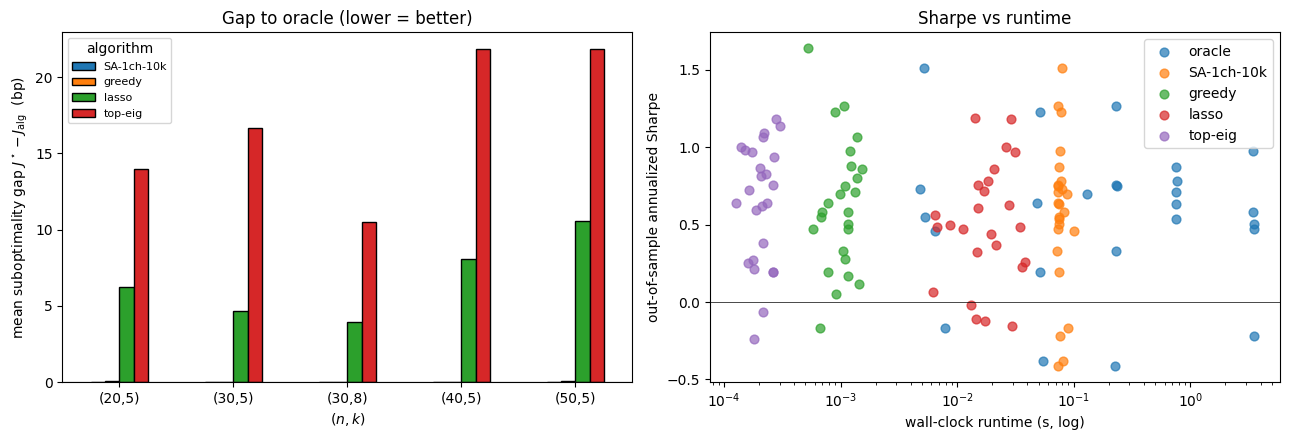

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
non_oracle = agg[agg["alg"] != "oracle"].copy()
non_oracle["label"] = non_oracle.apply(lambda r: f"({r['n']},{r['k']})", axis=1)
pivot_gap = non_oracle.pivot(index="label", columns="alg", values="gap_bp_mean")
pivot_gap.plot(kind="bar", ax=ax, edgecolor="black")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel(r"mean suboptimality gap $J^\star - J_{\rm alg}$  (bp)")
ax.set_xlabel(r"$(n, k)$")
ax.set_title("Gap to oracle (lower = better)")
ax.legend(title="algorithm", fontsize=8)
ax.tick_params(axis="x", rotation=0)

ax = axes[1]
for alg in alg_order:
    sub = results[results["alg"] == alg]
    if sub.empty:
        continue
    ax.scatter(sub["runtime_s"], sub["sharpe_test"], label=alg, alpha=0.7, s=40)
ax.set_xscale("log")
ax.set_xlabel("wall-clock runtime (s, log)")
ax.set_ylabel("out-of-sample annualized Sharpe")
ax.set_title("Sharpe vs runtime")
ax.axhline(0, color="black", lw=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "oracle_vs_baselines.png", dpi=120)
plt.show()

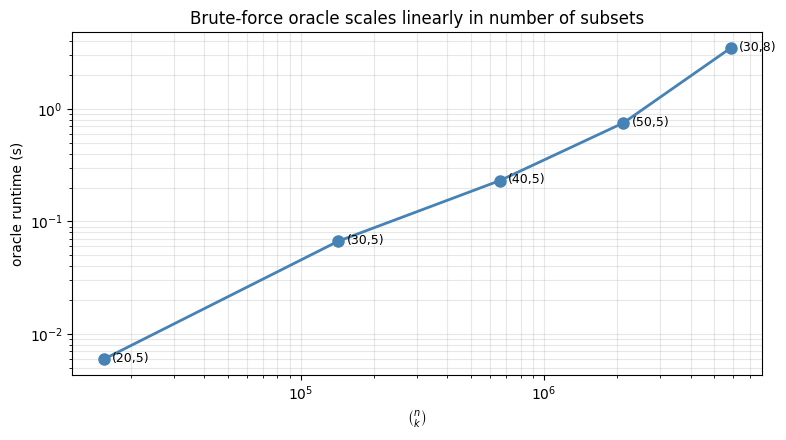

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
oracle_rt = results[results["alg"] == "oracle"].groupby(["n", "k"])["runtime_s"].mean().reset_index()
oracle_rt["nck"] = oracle_rt.apply(lambda r: comb(int(r["n"]), int(r["k"])), axis=1)
oracle_rt = oracle_rt.sort_values("nck")
ax.loglog(oracle_rt["nck"], oracle_rt["runtime_s"], "o-", color="steelblue", lw=2, ms=8)
for _, r in oracle_rt.iterrows():
    ax.annotate(f"({int(r['n'])},{int(r['k'])})", (r["nck"], r["runtime_s"]), textcoords="offset points", xytext=(6, -2), fontsize=9)
ax.set_xlabel(r"$\binom{n}{k}$")
ax.set_ylabel("oracle runtime (s)")
ax.set_title("Brute-force oracle scales linearly in number of subsets")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "oracle_runtime.png", dpi=120)
plt.show()

## 10. Save results for downstream phases

In [12]:
results.to_csv(DATA_DIR / "oracle_baselines.csv", index=False)
agg.to_csv(DATA_DIR / "oracle_baselines_agg.csv", index=False)

summary = {
    "gamma": GAMMA,
    "train_frac": TRAIN_FRAC,
    "trading_days": TRADING_DAYS,
    "grid": [{"n": n, "k": k, "n_subsets": comb(n, k)} for (n, k) in GRID],
    "n_instances": N_INSTANCES,
    "agg": json.loads(agg.to_json(orient="records")),
}
with open(DATA_DIR / "oracle_baselines.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved:", DATA_DIR / "oracle_baselines.json", "and .csv files")

Saved: data\oracle_baselines.json and .csv files


## What this gives us for Phases 3-5

1. **Ground truth $J^\star$** for every $(n,k)$ in the grid, on 5 distinct random instances each. The OGP empirical experiment in Phase 3b will plot the **overlap distribution** of MCMC samples against this ground truth $S^\star$.
2. A **baseline ladder** (top-eig $\to$ lasso $\to$ greedy $\to$ SA) showing how far each generic algorithm sits from the oracle. In Phase 4b we add the **hybrid spectral + local-improvement** algorithm and show it sits at the top of this ladder.
3. The **Sharpe-vs-runtime** scatter directly answers the practitioner's question: *is the extra optimization worth it on out-of-sample data?*, a question the writeup should not dodge.
4. Empirical evidence for the writeup that **LASSO is competitive on $J$ but not optimal**, lining up with the Phase 1 RIP-failure story.